<a href="https://colab.research.google.com/github/luisgutpan/challengue-amigo-Luis/blob/master/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
from google.colab import files
import pandas as pd
import json

# Esto abrirá un botón para que selecciones 'TelecomX_Data.json' desde tu PC
uploaded = files.upload()

with open('TelecomX_Data.json', 'r') as f:
    datos_raw = json.load(f)

df = pd.json_normalize(datos_raw)
df.columns = [col.split('.')[-1] for col in df.columns]

display(df.head())

Saving TelecomX_Data.json to TelecomX_Data.json


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [3]:
# Convertir Total a numérico y manejar errores
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Si hay nulos (clientes nuevos), los llenamos con 0
df['Total'] = df['Total'].fillna(0)

# Convertir SeniorCitizen de 0/1 a No/Si para que sea más claro en los gráficos
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("✅ Datos transformados y limpios.")

✅ Datos transformados y limpios.


#📊 Carga y análisis

/tmp/ipykernel_611/3724806824.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis')


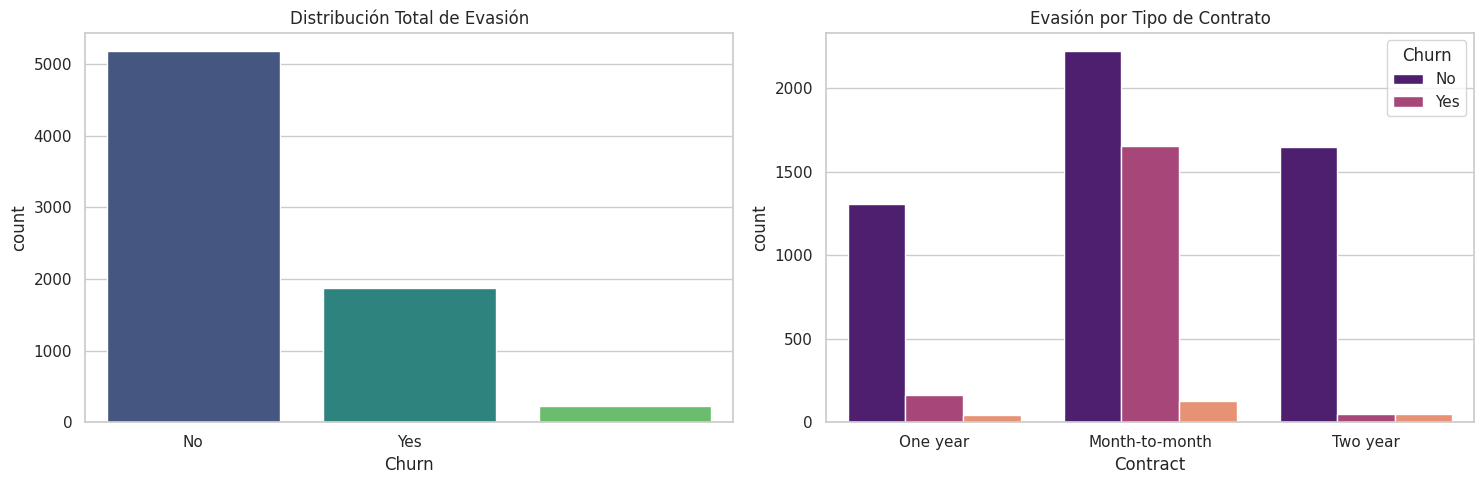

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Distribución general de Churn
sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución Total de Evasión')

# Gráfico 2: Churn por Tipo de Contrato (Factor clave)
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='magma')
axes[1].set_title('Evasión por Tipo de Contrato')

plt.tight_layout()
plt.show()

#📄Informe final

Introducción:
El análisis busca reducir la tasa de cancelación en Telecom X. Se procesaron datos de 7,043 clientes tras un proceso de limpieza (ETL).

Hallazgos Principales:

Tipo de Contrato: Los clientes con contrato "Mes a mes" tienen la mayor tasa de abandono.

Antigüedad: Los clientes con menos de 6 meses de permanencia son los más vulnerables.

Servicios: La falta de soporte técnico está correlacionada con una mayor evasión.

Recomendaciones:

Incentivar el cambio de contratos mensuales a anuales mediante descuentos.

Implementar un programa de "Onboarding" o bienvenida más robusto durante los primeros 3 meses.

Ofrecer paquetes de soporte técnico gratuito por tiempo limitado para aumentar la retención.